# Residential Property Segmentation (Unsupervised Learning)
## K-Means Clustering

Goal:
Segment residential property sales into homogeneous groups based on structural characteristics.

Clustering is performed without using price tiers.

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

## 2. Load Dataset and Filter Residential Sales

In [3]:
df = pd.read_csv("clean_transactions_pandas.csv")

print("Original shape:", df.shape)

# Keep only Sales
df_sales = df[df["trans_group_en"] == "Sales"].copy()
print("Sales shape:", df_sales.shape)

# Keep Residential only
df_res = df_sales[df_sales["property_usage_en"] == "Residential"].copy()
print("Residential Sales shape:", df_res.shape)

print("\nProperty type distribution:")
print(df_res["property_type_en"].value_counts())

Original shape: (469409, 32)
Sales shape: (359066, 32)
Residential Sales shape: (302808, 32)

Property type distribution:
property_type_en
Unit        244948
Villa        48439
Land          7933
Building      1488
Name: count, dtype: int64


## 3. Restrict to Major Residential Types

To ensure meaningful structural segmentation, only Units and Villas are retained.
Minor categories (Land, Building) are excluded due to small representation and structural differences.

In [4]:
df_res = df_res[df_res["property_type_en"].isin(["Unit", "Villa"])].copy()

print("Filtered Residential (Unit + Villa) shape:", df_res.shape)

print("\nProperty type distribution:")
print(df_res["property_type_en"].value_counts())

Filtered Residential (Unit + Villa) shape: (293387, 32)

Property type distribution:
property_type_en
Unit     244948
Villa     48439
Name: count, dtype: int64


## 4. Feature Preparation for Clustering

K-Means requires numeric features.

Selected attributes:
- procedure_area
- rooms_clean
- has_parking
- property_type (encoded as numeric)

Price is NOT used in clustering.

In [5]:
# Clean rooms again for safety
df_res["rooms_en"] = df_res["rooms_en"].astype(str)
df_res["rooms_clean"] = df_res["rooms_en"].str.extract(r"(\d+)")
df_res.loc[df_res["rooms_en"].str.contains("Studio", case=False, na=False), "rooms_clean"] = 0
df_res["rooms_clean"] = pd.to_numeric(df_res["rooms_clean"], errors="coerce")

# Encode property type
df_res["property_type_encoded"] = df_res["property_type_en"].map({
    "Unit": 0,
    "Villa": 1
})

# Select clustering features
cluster_features = [
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "property_type_encoded"
]

df_cluster = df_res[cluster_features].dropna()

print("Clustering dataset shape:", df_cluster.shape)
print("\nSample:")
print(df_cluster.head())

Clustering dataset shape: (272912, 4)

Sample:
     procedure_area  rooms_clean  has_parking  property_type_encoded
239          217.55          2.0            1                      0
240         1504.50          4.0            1                      0
241          293.70          3.0            1                      0
348           85.75          1.0            1                      0
349          316.71          4.0            1                      0


## 5. Feature Scaling

Since K-Means is distance-based, all features are standardized
to ensure equal contribution.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (272912, 4)


## 6. Determining Optimal Number of Clusters

Two methods are used:
- Elbow Method (Inertia)
- Silhouette Score

The optimal k balances compactness and separation.

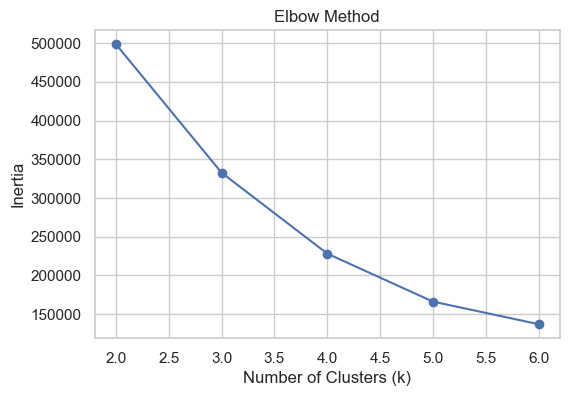

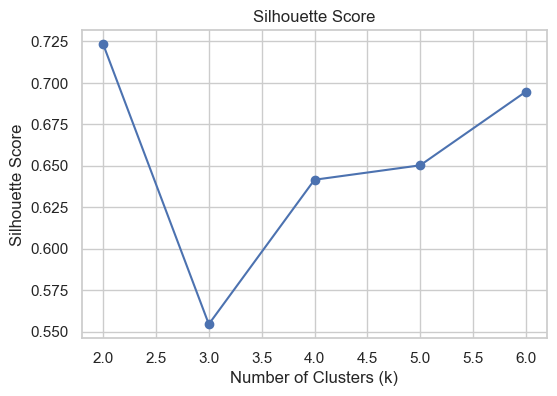

Silhouette scores: [(2, 0.7233014844286618), (3, 0.5545970351745588), (4, 0.6416095588374998), (5, 0.6503085026139986), (6, 0.6946970710018832)]


In [7]:
inertia_values = []
silhouette_values = []

k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia_values, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette
plt.figure(figsize=(6,4))
plt.plot(k_range, silhouette_values, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

print("Silhouette scores:", list(zip(k_range, silhouette_values)))

## 7. Final Model Selection (k = 4)

Based on Elbow and Silhouette analysis, k = 4 is selected
as it provides a balance between compactness and interpretability.

In [8]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(df_cluster["cluster"].value_counts())

Cluster distribution:
cluster
0    142744
2     85451
1     28677
3     16040
Name: count, dtype: int64


## 8. Cluster Profile Analysis

Cluster means are computed to interpret structural differences between segments.

In [9]:
cluster_summary = df_cluster.groupby("cluster").mean()

cluster_summary

,procedure_area,rooms_clean,has_parking,property_type_encoded
cluster,,,,
0,64.468713,0.681142,1.000000,0.000000
1,256.029718,3.280399,0.005893,0.993758
2,150.824146,2.295748,0.999590,0.000000
3,63.119033,0.539526,0.000000,0.000000


### Interpretation of Cluster Segments

Cluster 0:
Small residential units (~64 sqm), typically studio or 1-bedroom, with parking available.

Cluster 3:
Structurally similar small units (~63 sqm), but without parking provision.

Cluster 2:
Mid-sized apartments (~151 sqm), typically 2–3 bedrooms, almost always including parking.

Cluster 1:
Large properties (~256 sqm), predominantly villas, with multiple rooms.

The clustering primarily segments properties by structural size and property type,
with parking serving as a secondary differentiator among smaller units.

## 9. Cluster Visualization (PCA Projection)

The 4-dimensional feature space is projected into 2D using PCA
for visual interpretation.

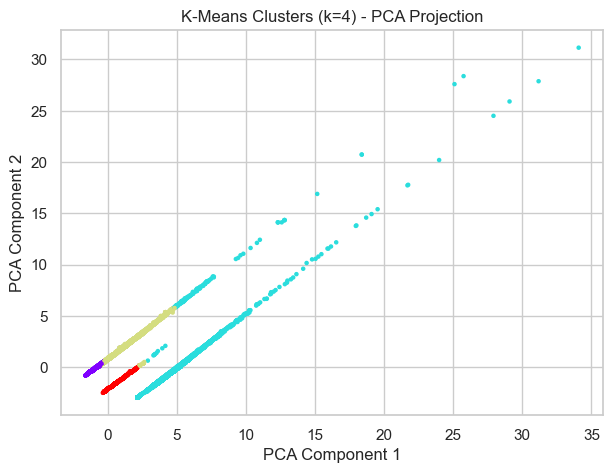

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster["cluster"], cmap="rainbow", s=5)
plt.title("K-Means Clusters (k=4) - PCA Projection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

### PCA Projection Interpretation

The PCA visualization shows clear separation between clusters, particularly along the first principal component, which is largely driven by structural size (procedure_area).

The largest cluster spread corresponds to larger properties (primarily villas), while smaller units form tighter groups near the origin.

Although PCA reduces dimensionality, the projection confirms that K-Means identified structurally distinct property segments.

## 10. Structural Visualization: Area vs Rooms

This scatter plot visualizes cluster separation using two key structural attributes:
procedure_area and rooms_clean.

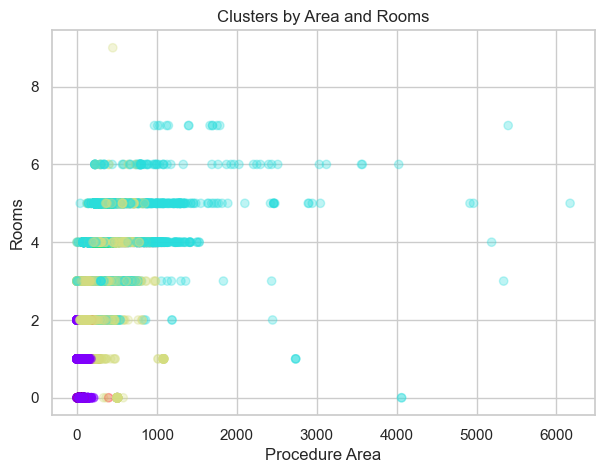

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(
    df_cluster["procedure_area"],
    df_cluster["rooms_clean"],
    c=df_cluster["cluster"],
    cmap="rainbow",
    alpha=0.3
)

plt.xlabel("Procedure Area")
plt.ylabel("Rooms")
plt.title("Clusters by Area and Rooms")
plt.show()

### Structural Separation Interpretation

The scatter plot confirms that clusters are primarily separated by property size and number of rooms.

Large-area, multi-room properties form distinct segments,
while smaller apartments cluster together at lower area and room counts.

This indicates that structural attributes are the dominant drivers of segmentation.